# Machine Larning

In [1]:
import pandas as pd
X = pd.read_excel("../data/Features_souches/matrice_bacteriocines_binaires_corrigee.xlsx")

In [2]:
X.head()

,Col gr A,Col gr B,MccV,MccC,MccIIa,MccJ25,MccL,Souche
0,1,0,0,0,0,0,0,952
1,0,1,0,0,0,0,0,955
2,1,0,0,0,0,1,0,958
3,0,0,0,0,0,0,0,959
4,1,0,0,0,0,1,0,982


## Exploration des données

In [3]:
import pandas as pd

data = pd.read_csv("../data/sortie/dataset_complet_sans_auto_inhibition.csv")

# Suppression des lignes contenant au moins un NaN
df = data.dropna()

print(f"Lignes avant nettoyage : {len(data)}")
print(f"Lignes après nettoyage : {len(df)}")
print(f"Lignes supprimées : {len(data) - len(df)}")


Lignes avant nettoyage : 1259
Lignes après nettoyage : 964
Lignes supprimées : 295


In [4]:
df.head()

,cible,productrice,couple,halo,Souche_P,ENA.AAA23068.AAA23068.1 Plasmid ColE2 hypothetical protein_P,ENA.AAA23074.AAA23074.1 Plasmid ColE8 hypothetical protein_P,ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein_P,ENA.AAA23081.AAA23081.1 Plasmid ColE6-CT14 hypothetical protein_P,ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein_P,...,FT4414_C,FT4415_C,FT4416_C,FT4417_C,FT4418_C,FT4419_C,FT4420_C,FT4421_C,FT4422_C,FT4423_C
0,1001,982,982_1001,0,982.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
2,1001,958,958_1001,0,958.0,0.0,0.0,1.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
4,1001,988,988_1001,0,988.0,0.0,0.0,0.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
5,1001,987,987_1001,0,987.0,0.0,0.0,0.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
6,1001,986,986_1001,0,986.0,0.0,0.0,0.0,0.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178


## Stat descriptive

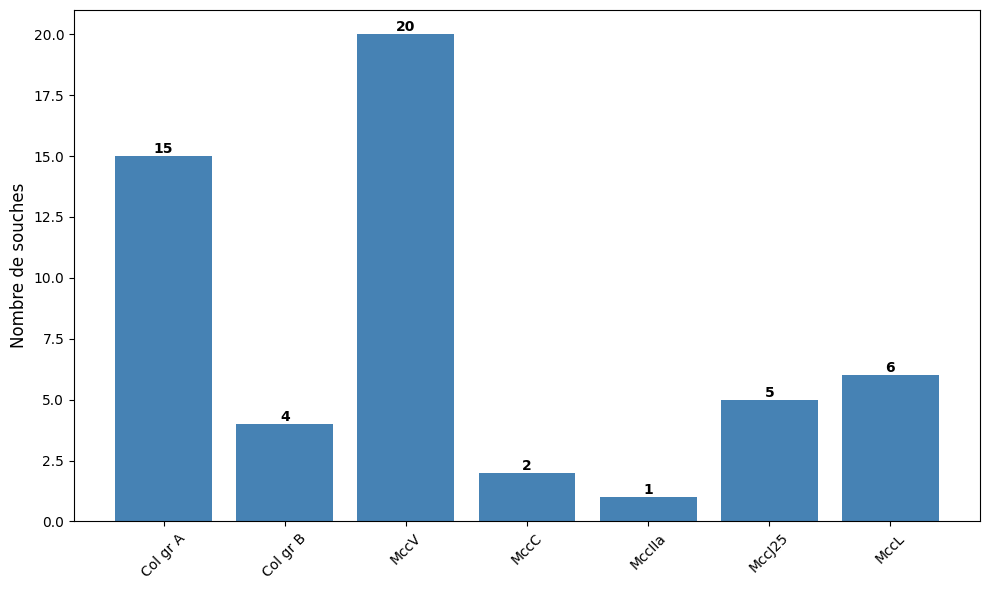

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# On enlève la colonne 'Souche' si elle existe
data = X.drop(columns=['Souche'], errors='ignore')

# On calcule la somme de chaque variable
sums = data.sum()

# Création du graphique en barres
plt.figure(figsize=(10,6))
bars = plt.bar(sums.index, sums.values, color='steelblue')

# Ajout des effectifs au bout des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Titres et labels
#plt.title('Distribution des variables', fontsize=14)
#plt.xlabel('Variables', fontsize=12)
plt.ylabel('Nombre de souches', fontsize=12)

# Rotation pour bien lire les étiquettes
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [6]:
# Fonction nettoyage et conversion en int
def normaliser_souches(series):
    """Nettoie les identifiants de souches : supprime espaces, convertit en int."""
    s = (series.astype(str)
               .str.strip()
               .str.replace(r"\s+", "", regex=True)
               .str.extract(r"(\d+)", expand=False))
    return pd.to_numeric(s, errors="coerce").dropna().astype(int)

# Application de la fonction
df["productrice"] = normaliser_souches(df["productrice"])
df["cible"] = normaliser_souches(df["cible"])
X["Souche"] = normaliser_souches(X["Souche"])

# Création de la colonne descriptive depuis la matrice binaire
colonnes_microcines = [col for col in X.columns if col != "Souche"]

def concat_microcines(row):
    actifs = [col for col in colonnes_microcines if row[col] == 1]
    return " + ".join(actifs) if actifs else "0"

X["Microcines / Colicines produites"] = X.apply(concat_microcines, axis=1)

In [7]:
import pandas as pd

# Liste des souches productrices présentes dans df
souches_productrices = set(df["productrice"].unique())
print(f"Nombre de souches productrices dans df : {len(souches_productrices)}")

# Filtrage des souches présentes dans le dataset des intéractions
df_filtre = (
    X[X["Souche"].isin(souches_productrices)]
    .sort_values("Souche")
    .reset_index(drop=True)
)

print(f"Nombre de souches communes (attendu ≈ 34) : {len(df_filtre)}")

# Vérification des différences
souches_X = set(X["Souche"].unique())
manquantes = sorted(souches_X - souches_productrices)
non_trouvees = sorted(souches_productrices - souches_X)

print(f"Souches de X absentes de df['productrice'] : {manquantes}")
print(f"Souches de df['productrice'] absentes de X : {non_trouvees}")

# Affichage
df_filtre = df_filtre[["Souche", "Microcines / Colicines produites"]]
df_filtre.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid #ccc',
    'font-size': '13px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                 ('font-weight', 'bold'),
                                 ('text-align', 'center')]}
]).set_caption("Souches productrices présentes dans le dataset principal")

Nombre de souches productrices dans df : 34
Nombre de souches communes (attendu ≈ 34) : 34
Souches de X absentes de df['productrice'] : [np.int64(952), np.int64(955), np.int64(959), np.int64(1048), np.int64(1054)]
Souches de df['productrice'] absentes de X : []


,Souche,Microcines / Colicines produites
0,958,Col gr A + MccJ25
1,982,Col gr A + MccJ25
2,984,Col gr B + MccV + MccC + MccJ25
3,985,0
4,986,0
5,987,MccIIa + MccJ25
6,988,0
7,990,Col gr A
8,992,0
9,993,Col gr B + MccL


In [8]:
import pandas as pd

# Liste des souches productrices présentes dans df
souches_productrices = set(df["productrice"].unique())
print(f"Nombre de souches productrices dans df : {len(souches_productrices)}")

# Filtrage des souches présentes dans le dataset des intéractions
df_filtre = (
    X[X["Souche"].isin(souches_productrices)]
    .sort_values("Souche")
    .reset_index(drop=True)
)

print(f"Nombre de souches communes (attendu ≈ 34) : {len(df_filtre)}")

# Vérification des différences
souches_X = set(X["Souche"].unique())
manquantes = sorted(souches_X - souches_productrices)
non_trouvees = sorted(souches_productrices - souches_X)

print(f"Souches de X absentes de df['productrice'] : {manquantes}")
print(f"Souches de df['productrice'] absentes de X : {non_trouvees}")

# Affichage horizontal
df_filtre = df_filtre[["Souche", "Microcines / Colicines produites"]].T  # <-- transposé ici
df_filtre.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid #ccc',
    'font-size': '13px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                 ('font-weight', 'bold'),
                                 ('text-align', 'center')]}
]).set_caption("Souches productrices présentes dans le dataset principal (vue horizontale)")

Nombre de souches productrices dans df : 34
Nombre de souches communes (attendu ≈ 34) : 34
Souches de X absentes de df['productrice'] : [np.int64(952), np.int64(955), np.int64(959), np.int64(1048), np.int64(1054)]
Souches de df['productrice'] absentes de X : []


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
Souche,958,982,984,985,986,987,988,990,992,993,994,995,996,998,999,1001,1003,1006,1008,1009,1011,1012,1014,1015,1017,1019,1020,1025,1028,1032,1033,1036,1041,1044
Microcines / Colicines produites,Col gr A + MccJ25,Col gr A + MccJ25,Col gr B + MccV + MccC + MccJ25,0,0,MccIIa + MccJ25,0,Col gr A,0,Col gr B + MccL,Col gr A + MccV + MccJ25,Col gr A + MccV + MccL,MccV,Col gr A + MccV,0,Col gr B + MccL,Col gr A + MccV + MccL,0,Col gr A + MccV + MccL,MccV,Col gr A + MccV + MccC,0,Col gr A + MccV,0,MccV,MccV,Col gr A + MccV,MccV + MccL,Col gr A + MccV,Col gr A + MccV,MccV,MccV,MccV,Col gr A + MccV


## Analyse Bivariée

### Souches inhibitrices

In [9]:
import pandas as pd

X["Peptides produits"] = X.apply(concat_microcines, axis=1)

# Calcul du nombre de cibles testées et inhibées
inhibition_par_productrice = (
    df[df["halo"] == 1]
    .groupby("productrice")["cible"]
    .nunique()
    .reset_index(name="nb_souches_inhibées")
)
total_cibles = df.groupby("productrice")["cible"].nunique().reset_index(name="nb_cibles_testées")

# Fusion des deux tableaux
stats_productrices = pd.merge(total_cibles, inhibition_par_productrice, on="productrice", how="left").fillna(0)

# Calcul du taux d’inhibition
stats_productrices["taux_inhibition_%"] = (
    100 * stats_productrices["nb_souches_inhibées"] / stats_productrices["nb_cibles_testées"]
).round(1)

# Ajout des peptides produits (depuis X)
stats_productrices["productrice"] = stats_productrices["productrice"].astype(int)
X["Souche"] = X["Souche"].astype(int)

stats_productrices = stats_productrices.merge(
    X[["Souche", "Peptides produits"]],
    left_on="productrice",
    right_on="Souche",
    how="left"
).drop(columns="Souche")

# Réorganisation des colonnes et tri final
stats_productrices = stats_productrices[
    ["productrice", "Peptides produits", "nb_cibles_testées", "nb_souches_inhibées", "taux_inhibition_%"]
].sort_values("nb_souches_inhibées", ascending=False).reset_index(drop=True)

# Affichage
stats_productrices.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid #ccc',
    'font-size': '13px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                 ('font-weight', 'bold'),
                                 ('text-align', 'center')]}
]).set_caption("Souches productrices : peptides produits et nombre de souches inhibées")

,productrice,Peptides produits,nb_cibles_testées,nb_souches_inhibées,taux_inhibition_%
0,996,MccV,28,13.000000,46.400000
1,984,Col gr B + MccV + MccC + MccJ25,21,10.000000,47.600000
2,1025,MccV + MccL,26,10.000000,38.500000
3,1001,Col gr B + MccL,27,9.000000,33.300000
4,1008,Col gr A + MccV + MccL,28,9.000000,32.100000
5,994,Col gr A + MccV + MccJ25,24,9.000000,37.500000
6,982,Col gr A + MccJ25,20,8.000000,40.000000
7,958,Col gr A + MccJ25,18,7.000000,38.900000
8,1003,Col gr A + MccV + MccL,26,7.000000,26.900000
9,987,MccIIa + MccJ25,20,7.000000,35.000000


### Souche inhibées

In [10]:
import pandas as pd

X["Peptides produits (par la cible)"] = X.apply(concat_microcines, axis=1)

# Statistiques sur les souches CIBLES
tests_par_cible = (
    df.groupby("cible")["productrice"]
    .nunique()
    .reset_index(name="nb_productrices_testées")
)

inhibition_par_cible = (
    df[df["halo"] == 1]
    .groupby("cible")["productrice"]
    .nunique()
    .reset_index(name="nb_productrices_inhibitrices")
)

stats_cibles = pd.merge(tests_par_cible, inhibition_par_cible, on="cible", how="left").fillna(0)

# Calcul du taux d’inhibition
stats_cibles["taux_inhibition_%"] = (
    100 * stats_cibles["nb_productrices_inhibitrices"] / stats_cibles["nb_productrices_testées"]
).round(1)

# Ajout des peptides produits (depuis X)
stats_cibles["cible"] = stats_cibles["cible"].astype(int)
X["Souche"] = X["Souche"].astype(int)

stats_cibles = stats_cibles.merge(
    X[["Souche", "Peptides produits (par la cible)"]],
    left_on="cible",
    right_on="Souche",
    how="left"
).drop(columns="Souche")

# Réorganisation des colonnes et tri final
stats_cibles = stats_cibles[
    ["cible", "Peptides produits (par la cible)",
     "nb_productrices_testées", "nb_productrices_inhibitrices", "taux_inhibition_%"]
].sort_values("nb_productrices_inhibitrices", ascending=False).reset_index(drop=True)

# Affichage
stats_cibles.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid #ccc',
    'font-size': '13px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                 ('font-weight', 'bold'),
                                 ('text-align', 'center')]}
]).set_caption("Souches cibles : peptides produits et nombre de productrices inhibitrices")

,cible,Peptides produits (par la cible),nb_productrices_testées,nb_productrices_inhibitrices,taux_inhibition_%
0,1006,0,28,26.000000,92.900000
1,988,0,28,25.000000,89.300000
2,999,0,28,22.000000,78.600000
3,985,0,25,20.000000,80.000000
4,986,0,22,17.000000,77.300000
5,1012,0,19,12.000000,63.200000
6,1028,Col gr A + MccV,29,10.000000,34.500000
7,992,0,16,9.000000,56.200000
8,1009,MccV,27,7.000000,25.900000
9,1044,Col gr A + MccV,26,6.000000,23.100000


### Croisée

In [11]:
import pandas as pd
import numpy as np

# Nombre de cibles inhibées (productrice → cible)
inhibition_par_souche = (
    df[df["halo"] == 1]
    .groupby("productrice")["cible"]
    .nunique()
    .reset_index(name="nb_souches_inhibées")
)

#  Nombre de fois où chaque souche a été inhibée (en tant que cible)
inhibiteurs_par_souche = (
    df[df["halo"] == 1]
    .groupby("cible")["productrice"]
    .nunique()
    .reset_index(name="nb_souches_inhibitrices")
)

# Fusion et remplissage des valeurs manquantes
stats_souches = pd.merge(
    df[["productrice"]].drop_duplicates(),
    inhibition_par_souche,
    on="productrice",
    how="left"
).merge(
    inhibiteurs_par_souche,
    left_on="productrice",
    right_on="cible",
    how="left"
).drop(columns="cible").fillna(0)

# Ajout des peptides produits (depuis X)
stats_souches = stats_souches.merge(
    X[["Souche", "Peptides produits"]],
    left_on="productrice",
    right_on="Souche",
    how="left"
).drop(columns="Souche")

# Calcul de l’indice de compétitivité non biaisé
stats_souches["indice_competitivite"] = (
    (stats_souches["nb_souches_inhibées"] - stats_souches["nb_souches_inhibitrices"]) /
    (stats_souches["nb_souches_inhibées"] + stats_souches["nb_souches_inhibitrices"])
)

# Gestion des divisions par zéro → valeur neutre = 0
stats_souches["indice_competitivite"] = (
    stats_souches["indice_competitivite"].replace([np.inf, -np.inf], 0).fillna(0)
)

# Organisation finale
stats_souches = stats_souches.rename(columns={"productrice": "Souche"})
stats_souches = stats_souches[
    ["Souche", "Peptides produits", "nb_souches_inhibées",
     "nb_souches_inhibitrices", "indice_competitivite"]
].sort_values("indice_competitivite", ascending=False).reset_index(drop=True)

# Affichage du tableau
styled = stats_souches.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid #ccc',
    'font-size': '13px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                 ('font-weight', 'bold'),
                                 ('text-align', 'center')]}
]).set_caption("Indice de compétitivité des souches productrices (non biaisé)")

display(styled)

,Souche,Peptides produits,nb_souches_inhibées,nb_souches_inhibitrices,indice_competitivite
0,982,Col gr A + MccJ25,8.000000,0.000000,1.000000
1,958,Col gr A + MccJ25,7.000000,0.000000,1.000000
2,987,MccIIa + MccJ25,7.000000,0.000000,1.000000
3,984,Col gr B + MccV + MccC + MccJ25,10.000000,0.000000,1.000000
4,1003,Col gr A + MccV + MccL,7.000000,0.000000,1.000000
5,990,Col gr A,3.000000,0.000000,1.000000
6,1015,0,7.000000,0.000000,1.000000
7,1014,Col gr A + MccV,7.000000,0.000000,1.000000
8,1019,MccV,6.000000,0.000000,1.000000
9,1008,Col gr A + MccV + MccL,9.000000,0.000000,1.000000


In [12]:
!pip install adjustText

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


1 [-0.91832617  0.92796006]
2 [-0.8368779  -0.42798204]
6 [-0.56250025  0.83217245]
7 [-0.95006163 -0.03005741]


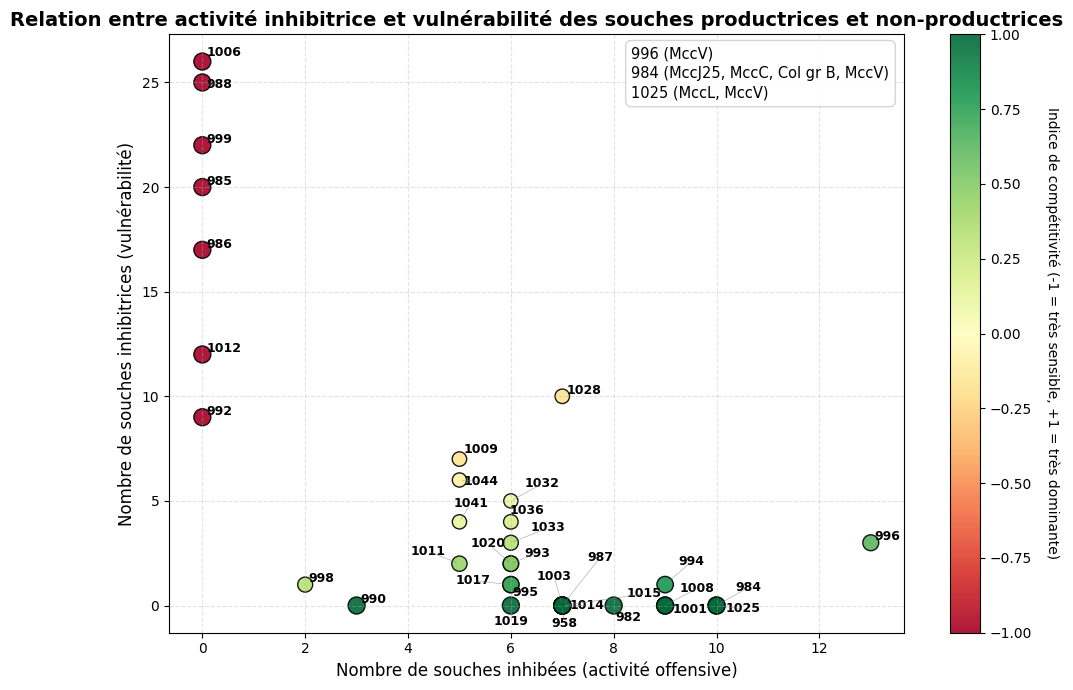

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# Détection automatique du nom de colonne
if "Souche" in stats_souches.columns:
    col_souche = "Souche"
elif "productrice" in stats_souches.columns:
    col_souche = "productrice"
else:
    raise KeyError("Aucune colonne 'Souche' ou 'productrice' trouvée dans stats_souches.")

# On garde toutes les souches (productrices et non productrices)
df_plot = stats_souches.copy().sort_values("indice_competitivite", ascending=False)

# Définition de la plage de couleur centrée sur 0 (−1 → +1)
vmin, vmax = -1, 1

# Scatterplot
plt.figure(figsize=(10, 7))

sc = plt.scatter(
    df_plot["nb_souches_inhibées"],
    df_plot["nb_souches_inhibitrices"],
    c=df_plot["indice_competitivite"],
    cmap="RdYlGn",
    vmin=vmin,
    vmax=vmax,
    s=100 + 50 * np.abs(df_plot["indice_competitivite"]),
    edgecolor="k",
    alpha=0.9
)

plt.xlabel("Nombre de souches inhibées (activité offensive)", fontsize=12)
plt.ylabel("Nombre de souches inhibitrices (vulnérabilité)", fontsize=12)
plt.title(
    "Relation entre activité inhibitrice et vulnérabilité des souches productrices et non-productrices",
    fontsize=14,
    weight="bold"
)
plt.grid(True, linestyle="--", alpha=0.35)

#  Barre de couleur
cbar = plt.colorbar(sc)
cbar.set_label("Indice de compétitivité (-1 = très sensible, +1 = très dominante)", rotation=270, labelpad=20)
cbar.set_ticks(np.linspace(-1, 1, 9))

# Annotations intelligentes
texts = []
for _, row in df_plot.iterrows():
    txt = plt.text(
        row["nb_souches_inhibées"],
        row["nb_souches_inhibitrices"],
        str(int(row[col_souche])),
        fontsize=9,
        weight="bold",
        color="black"
    )
    texts.append(txt)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6),
    expand_text=(1.1, 1.3),
    force_points=0.2,
    force_text=0.6,
    lim=500
)

# Cadrant d'information (en haut à droite, texte aligné à gauche)
info_text = (
    "996 (MccV)\n"
    "984 (MccJ25, MccC, Col gr B, MccV)\n"
    "1025 (MccL, MccV)"
)

plt.text(
    0.98, 0.98,  # position : coin supérieur droit
    info_text,
    transform=plt.gca().transAxes,
    fontsize=10.5,
    verticalalignment='top',
    horizontalalignment='right',  # cadrant reste ancré à droite
    linespacing=1.4,
    color='black',
    bbox=dict(
        facecolor='white',
        edgecolor='lightgray',
        boxstyle='round,pad=0.4',
        alpha=0.95
    ),
    multialignment='left'  # <-- alignement du texte à gauche à l'intérieur du cadrant
)

plt.tight_layout()
plt.show()